# 11. Attention Made Visible: Gaussians, KDE, Heatmaps

Eye trackers record where people look; heatmaps turn the looking itself into a picture. Today we simulate an audience for a conference poster, build kernel density estimation with our own hands, and learn why every attention heatmap is an argument wearing the costume of a measurement.

## Today's destination

A conference poster and the ghost of its audience: two hundred simulated fixations, blurred into a glowing density of attention and composited onto the page. Nobody ever actually looked at this poster; the fixations are invented, and saying so out loud is part of today's lesson. By the end of today you can turn any list of points into a heatmap, and you will know every dial that quietly shapes what such a picture seems to prove.

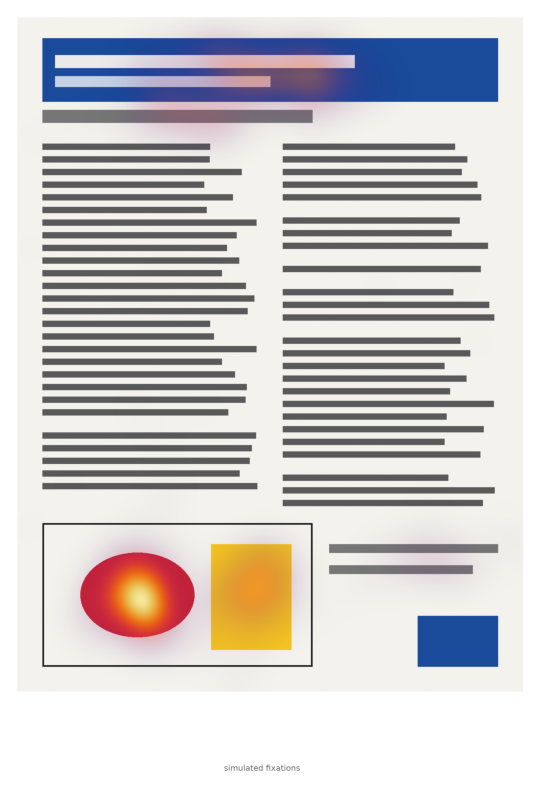

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch11_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(7.5, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the observer observed

In 1965 the Soviet psychologist **Alfred Yarbus** published a slim book, *Eye Movements and Vision* (English translation 1967), containing what may be the most reproduced figure in all of vision science. Yarbus attached a tiny mirror to the eye with a suction cap and recorded, with unprecedented precision, the path a viewer's gaze traveled across a picture. His most famous material was a painting: Ilya Repin's *An Unexpected Visitor* (usually catalogued as *They Did Not Expect Him*, 1884–88, Tretyakov Gallery), a returned exile stepping into a family parlor. Yarbus had one viewer examine it seven times, first freely, then with a different errand each time: estimate the family's wealth, estimate their ages, memorize the positions of people and objects, judge how long the visitor had been away. The seven recorded traces look like seven different drawings. Asked about wealth, the gaze combs furniture and clothing; asked about ages, it orbits the faces and barely leaves them. The picture never changed; the question did. **Where we look is a property not of the image alone but of the errand we bring to it**, and that single plate founded a research tradition.

That tradition has since walked out of the laboratory and into the museum. Wearable eye trackers, ordinary-looking glasses with cameras aimed at the eye and at the world, now record visitors moving freely through real galleries, and a small research field asks what paintings do to gazes outside laboratory conditions: how long visitors actually dwell, what they fixate first, how experts and novices differ. This happens to be the instructor's own research field, and this is the point in the session where the notebook steps aside for some real recordings.

<!-- INSTRUCTOR: insert 2-3 slides/images from own Leopold Museum work -->

The standard summary picture of such recordings is the **attention heatmap**: fixations pooled over viewers, blurred into a smooth density, painted over the artwork in glowing false color. Heatmaps are genuinely useful, and they are also rhetoric. They *look* like objective instrument output, the weather map of a collective gaze, yet nearly everything about their appearance is authored: how much to blur, which colors mean "hot", how transparent the overlay, where the scale is cut off. Two honest heatmaps of the same data can whisper different conclusions. Today we build the whole pipeline ourselves precisely so that you know which knobs exist and who turned them.

One rule before we begin. Our fixations today are **simulated**: plausible, designed, fake, and every figure will say so. A fabricated heatmap presented as measurement would be a small act of scientific forgery; the same picture labeled *simulated* is a legitimate design tool, a hypothesis you can draw. The difference is one word in the caption, which is exactly why the word matters.

## The bell curve is a brush

Chapter 2 introduced `rng.normal` and the histogram it produces: the bell curve. Now we meet the curve itself as a function, the **Gaussian**:

$$g(x) = \frac{1}{\sigma\sqrt{2\pi}}\; e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

Two dials: $\mu$ slides the bump along the axis, $\sigma$ sets its width. Everything else in that formula is bookkeeping that makes the area under the curve exactly 1. (The letter $e$ is simply a fixed number, roughly 2.718; `np.exp` computes its powers. All we ever need from it: $e^0 = 1$, and $e^{-t}$ dives toward 0 as $t$ grows, which is what makes the curve fall away from its peak.) For pictures, the shape is what matters:

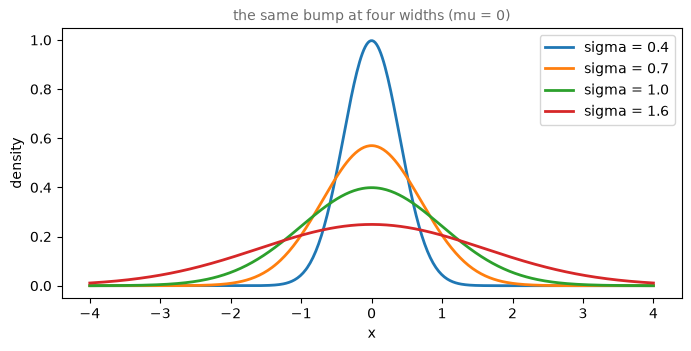

In [2]:
# the Gaussian: one bump, two dials (position mu, width sigma)
import numpy as np

x = np.linspace(-4, 4, 400)
plt.figure(figsize=(8, 3.5))
for sigma in [0.4, 0.7, 1.0, 1.6]:
    curve = np.exp(-x**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    plt.plot(x, curve, linewidth=2, label=f"sigma = {sigma}")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.title("the same bump at four widths (mu = 0)", fontsize=10, color="#6B6B6B")
plt.show()

**Try it.** Edit the previous cell's list of sigmas (add a tiny 0.2 or a huge 3.0) and rerun it; predict the new curve before you look.

A wide $\sigma$ trades height for width: the area stays 1, like the same amount of paint brushed thinner. In two dimensions the bump becomes a hill. We drop the normalizing constant from here on (for pictures only relative height matters):

$$g(x, y) = e^{-\frac{(x-x_0)^2 + (y-y_0)^2}{2\sigma^2}}$$

Remember `np.meshgrid` from chapter 7? It returns the coordinate tables we need to evaluate this on every pixel at once.

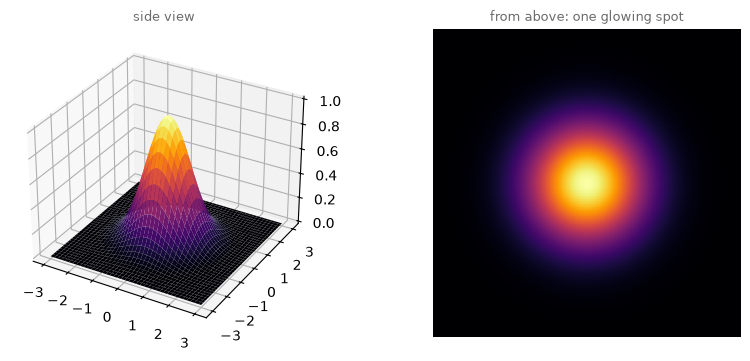

In [3]:
# one fixation becomes a hill: the same 2D Gaussian from the side and from above
grid_x, grid_y = np.meshgrid(np.linspace(-3, 3, 120), np.linspace(-3, 3, 120))
bump = np.exp(-(grid_x**2 + grid_y**2) / (2 * 0.8**2))

fig = plt.figure(figsize=(10, 4))
side = fig.add_subplot(1, 2, 1, projection="3d")   # 3D axes, view only
side.plot_surface(grid_x, grid_y, bump, cmap="inferno")
side.set_title("side view", fontsize=9, color="#6B6B6B")
above = fig.add_subplot(1, 2, 2)
above.imshow(bump, cmap="inferno")
above.set_title("from above: one glowing spot", fontsize=9, color="#6B6B6B")
above.axis("off")
plt.show()

## A sum of bumps: kernel density estimation

Here is the entire idea behind every heatmap you have ever seen. Given $N$ data points, place one Gaussian bump on each and **add them up**:

$$D(x, y) = \sum_{i=1}^{N} e^{-\frac{(x-x_i)^2 + (y-y_i)^2}{2\sigma^2}}$$

Statisticians call this **kernel density estimation** (Kerndichteschätzung), KDE for short: the bump is the *kernel*, and the sum estimates how densely the points cover the plane. The width $\sigma$ is called the **bandwidth**, and it leads a double life. Statistically it is a smoothing parameter: too small and you see individual data points, too large and all structure melts into one blob. Aesthetically it is a brush size. Both lives matter today. First in one dimension, where we can watch the sum happen:

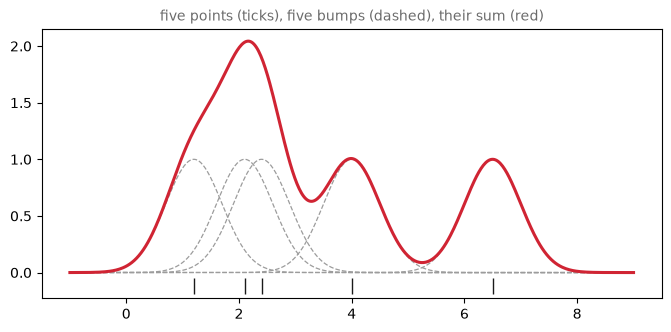

In [4]:
# KDE by hand in 1D: five data points, five bumps, one sum
points = [1.2, 2.1, 2.4, 4.0, 6.5]
sigma = 0.5
x = np.linspace(-1, 9, 500)

density = np.zeros_like(x)
plt.figure(figsize=(8, 3.5))
for p in points:
    bump = np.exp(-(x - p)**2 / (2 * sigma**2))
    plt.plot(x, bump, color="#9C9C9C", linewidth=0.9, linestyle="--")
    density = density + bump
plt.plot(x, density, color="#D02433", linewidth=2.2)
plt.plot(points, np.full(len(points), -0.12), "|", color="#1A1A1A", markersize=12)
plt.title("five points (ticks), five bumps (dashed), their sum (red)",
          fontsize=10, color="#6B6B6B")
plt.show()

The two close points at 2.1 and 2.4 merge into a single hill taller than any lone bump: density rewards *company*. The isolated point at 6.5 keeps its modest solo hill.

**Try it.** Rerun the cell with `sigma = 0.1` and then `sigma = 1.5`. At the small bandwidth the pair separates into two peaks; at the large one all five points fuse into a single dune. The question "at which $\sigma$ do two points become one hill?" is the entire bandwidth debate in miniature.

## A poster and its simulated audience

Our canvas is a fake conference poster, generated synthetically by the course's image script. (If the file is missing, run `python assets/images/get_images.py` once in a terminal, from the book's main folder.) It has everything a real poster has: a title block, an author line, two text columns, one figure, a caption.

Where would people look? For real design work the instructor's workflow is charmingly manual: open the image in Photoshop or any editor, click colored dots onto a new layer wherever you believe a viewer's gaze would land, export the dot layer as a PNG, and extract the dot coordinates in Python (`np.argwhere` on the dot color does it). Today we skip the clicking and let `rng.normal` play the audience instead: for each region of the poster we invent a cluster of fixations, Gaussian around the region's center, plus a handful of strays. Chapter 2's controlled randomness, now impersonating human attention.

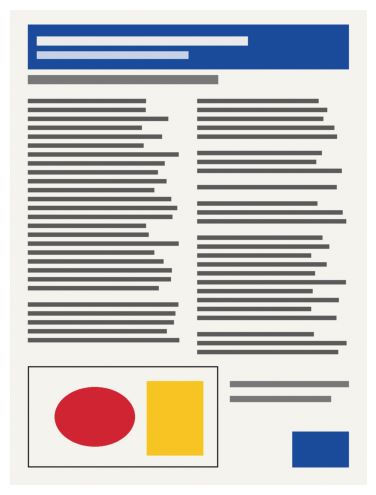

poster array: (1600, 1200, 3)


In [5]:
# load the fake conference poster (a synthetic image, built by get_images.py)
from PIL import Image

poster = np.asarray(Image.open("../assets/images/poster_demo.png")) / 255
height, width = poster.shape[:2]

plt.figure(figsize=(4.6, 6.2))
plt.imshow(poster)
plt.axis("off")
plt.show()
print("poster array:", poster.shape)

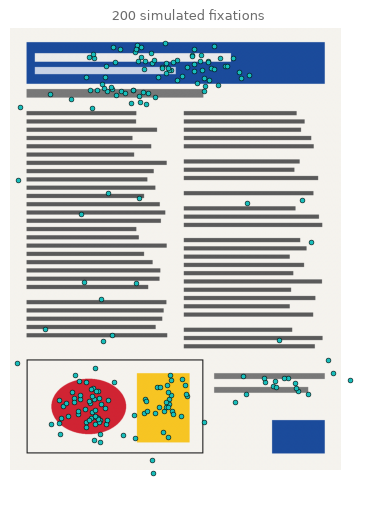

In [6]:
# simulate an audience: Gaussian fixation clusters on the busy regions
rng = np.random.default_rng(11)

# each region: (center_x, center_y, spread_x, spread_y, fixation count)
regions = [
    (600, 125, 170, 40, 60),     # title block
    (380, 235, 110, 18, 20),     # author line
    (285, 1370, 70, 60, 50),     # red shape in the figure
    (555, 1375, 55, 65, 30),     # yellow panel in the figure
    (940, 1285, 110, 30, 15),    # caption lines
]
fix_x, fix_y = [], []
for center_x, center_y, spread_x, spread_y, count in regions:
    # .extend appends a whole batch at once (chapter 0's .append, plural)
    fix_x.extend(rng.normal(center_x, spread_x, count))
    fix_y.extend(rng.normal(center_y, spread_y, count))
fix_x.extend(rng.uniform(0, width, 25))     # strays: nobody reads everything
fix_y.extend(rng.uniform(0, height, 25))
fix_x, fix_y = np.array(fix_x), np.array(fix_y)

plt.figure(figsize=(4.6, 6.2))
plt.imshow(poster)
plt.scatter(fix_x, fix_y, s=12, color="#17BEBB", edgecolor="black", linewidth=0.4)
plt.axis("off")
plt.title(f"{len(fix_x)} simulated fixations", fontsize=9, color="#6B6B6B")
plt.show()

Note what the simulation quietly claims: titles get read, figures get stared at, body text gets skimmed, and a few glances land nowhere in particular. Those are design hypotheses, not measurements. (As everywhere in this book: change the seed and a different audience shows up.)

## The heatmap by hand

A heatmap is nothing but our sum of bumps evaluated on a pixel grid. The recipe: build a coordinate grid with `np.meshgrid`, start from zeros, loop over the fixations, add one 2D bump per fixation. We keep the grid coarse on purpose: 90 x 120 cells times 200 fixations is already 2.2 million exponentials, and the point of doing it manually is to *see the sum*, not to win a race.

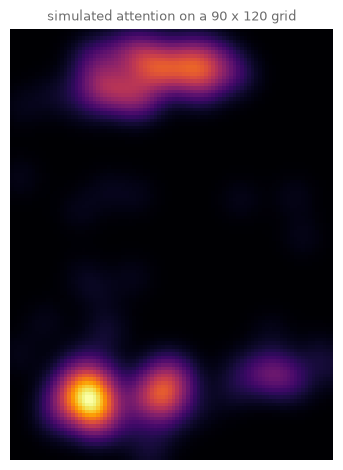

In [7]:
# manual KDE: loop over the fixations, add one bump per fixation to a grid
def kde_manual(xs, ys, bandwidth, grid_w, grid_h):
    # reads the poster's width/height from above; the finished generator
    # later asks the image itself
    grid_x, grid_y = np.meshgrid(np.linspace(0, width, grid_w),
                                 np.linspace(0, height, grid_h))
    density = np.zeros_like(grid_x)
    for x, y in zip(xs, ys):
        density += np.exp(-((grid_x - x)**2 + (grid_y - y)**2)
                          / (2 * bandwidth**2))
    return density

coarse = kde_manual(fix_x, fix_y, bandwidth=60, grid_w=90, grid_h=120)

plt.figure(figsize=(4.2, 5.6))
plt.imshow(coarse, cmap="inferno")
plt.axis("off")
plt.title("simulated attention on a 90 x 120 grid", fontsize=9, color="#6B6B6B")
plt.show()

Five glowing islands, one per invented region: the arithmetic worked. Look closer, though: the brightest island is not the title, which received the most fixations, but the red shape, whose fifty fixations huddle tightest. Density rewards concentration, not head count (a lesson exercise (b) returns to). The library version of the same idea is `scipy.stats.gaussian_kde`. It does two things for us: its inner loop runs in fast compiled code, so a much finer grid costs nothing, and it chooses the bandwidth *for* you with a statistical recipe (Scott's rule, derived from the number of points and their spread). Automatic bandwidth is the right default for statistics; for art we will want our pixel-sized $\sigma$ dial back, which is why the manual version stays in the toolbox.

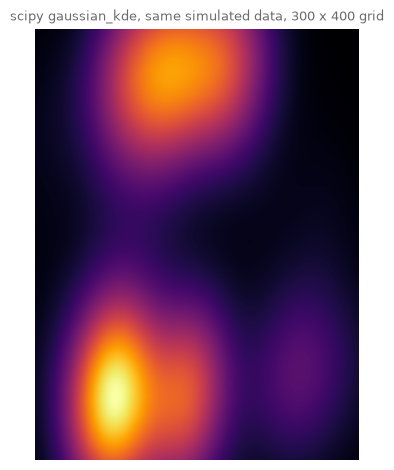

In [8]:
# the library version: scipy's gaussian_kde, fine grid, automatic bandwidth
from scipy.stats import gaussian_kde

kde = gaussian_kde(np.vstack([fix_x, fix_y]))   # vstack: two lists as rows
grid_x, grid_y = np.meshgrid(np.linspace(0, width, 300),
                             np.linspace(0, height, 400))
fine = kde(np.vstack([grid_x.ravel(), grid_y.ravel()])).reshape(grid_x.shape)

plt.figure(figsize=(4.2, 5.6))
plt.imshow(fine, cmap="inferno")
plt.axis("off")
plt.title("scipy gaussian_kde, same simulated data, 300 x 400 grid",
          fontsize=9, color="#6B6B6B")
plt.show()

## The overlay, and the honesty of colormaps

A heatmap floating alone says little; it wants to lie on top of the thing that was looked at. Layering is **alpha compositing**: with opacity $\alpha$, each screen pixel shows

$$\text{result} = \alpha \cdot \text{heat} + (1 - \alpha) \cdot \text{poster}$$

In matplotlib we simply call `imshow` twice, the second time with `alpha=`. The remaining choice is the colormap, and it is not innocent. Chapter 5 taught that equal steps in RGB are not equal steps to the eye; colormaps inherit the problem. The classic `jet` rainbow has bright bands in physically arbitrary places, so it *invents* edges and hotspots that do not exist in the data. `magma` and `inferno` are perceptually uniform: equal data steps look like equal steps, all the way up. Compare the same density in all three:

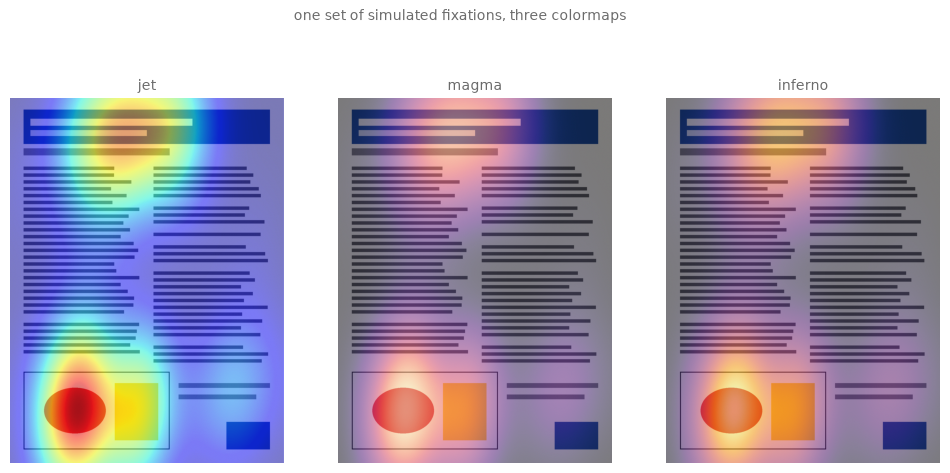

In [9]:
# same data three ways: the colormap is an editorial decision
fig, axes = plt.subplots(1, 3, figsize=(12, 5.6))
for ax, cmap in zip(axes, ["jet", "magma", "inferno"]):
    ax.imshow(poster)
    # extent= stretches the density grid over the poster's pixel coordinates
    ax.imshow(fine, cmap=cmap, alpha=0.5, extent=[0, width, height, 0])
    ax.set_title(cmap, fontsize=10, color="#6B6B6B")
    ax.axis("off")
fig.suptitle("one set of simulated fixations, three colormaps",
             fontsize=10, color="#6B6B6B")
plt.show()

**Look and compare.** Under `jet`, the cyan-to-yellow band draws crisp rings around every island, and the mid-density areas pop forward; the map seems to report sharp "zones" of attention. Under `inferno` the same data fades smoothly from nothing to bright. Which rendering would you rather publish if you *wanted* the title to look dominant? That question has an uncomfortable answer, which is the point: the perceptually uniform maps are not prettier, they are more honest.

**Try it.** In the cell above, change `alpha=0.5` to `0.2` and then `0.8`. At 0.8 the poster nearly disappears under the data; at 0.2 the data becomes a rumor. There is no neutral setting; there are only choices.

## The finished generator

One refinement separates our plots so far from a professional overlay. A flat `alpha=0.5` fogs the *entire* poster, including regions nobody looked at. Better: let the heat layer's transparency follow the density itself, transparent where cold, opaque where hot. A colormap call like `plt.get_cmap("inferno")(density)` returns an RGBA image (chapter 5's RGB plus an **alpha channel**), and we overwrite that fourth channel with the normalized density. One last dial: raising the density to a small power first (`fade`) pushes the faintest regions to full transparency, so stray glances do not smudge the clean paper. Cold regions then show the pristine poster, hot regions glow, and yes, `fade` is one more authored choice to disclose.

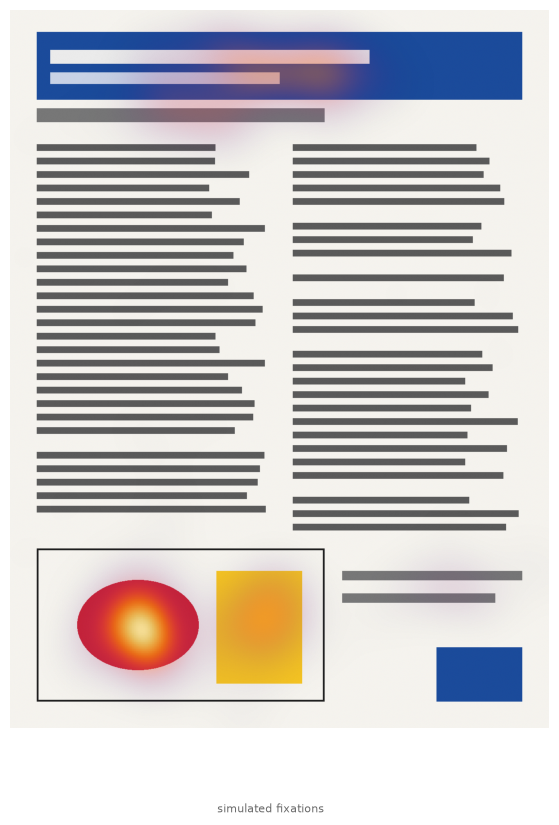

In [10]:
# the finished generator: fixations in, print-ready attention picture out
import sys
sys.path.append("..")
from agap.helpers import save_artwork

def attention_map(xs, ys, image, bandwidth=60, strength=0.85, fade=1.6,
                  cmap="inferno", grid_step=4, figsize=7):
    h, w = image.shape[:2]
    # np.arange: like range, but a numpy array (every grid_step-th pixel)
    grid_x, grid_y = np.meshgrid(np.arange(0, w, grid_step),
                                 np.arange(0, h, grid_step))
    density = np.zeros_like(grid_x, dtype=float)
    for x, y in zip(xs, ys):
        density += np.exp(-((grid_x - x)**2 + (grid_y - y)**2)
                          / (2 * bandwidth**2))
    density /= density.max()
    heat = plt.get_cmap(cmap)(density)             # RGBA image from the colormap
    # [..., 3] selects channel 3 (alpha) at every pixel
    heat[..., 3] = density**fade * strength        # alpha follows density
    fig = plt.figure(figsize=(figsize, figsize * h / w))
    plt.imshow(image)
    plt.imshow(heat, extent=[0, w, h, 0])
    plt.axis("off")
    fig.text(0.5, 0.02, "simulated fixations", ha="center",
             fontsize=8, color="#6B6B6B")
    plt.show()
    return fig

art_1 = attention_map(fix_x, fix_y, poster)

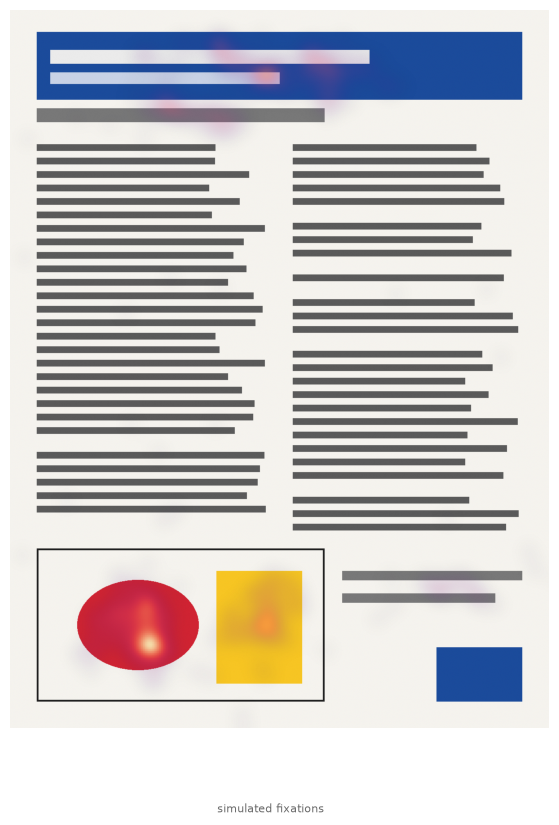

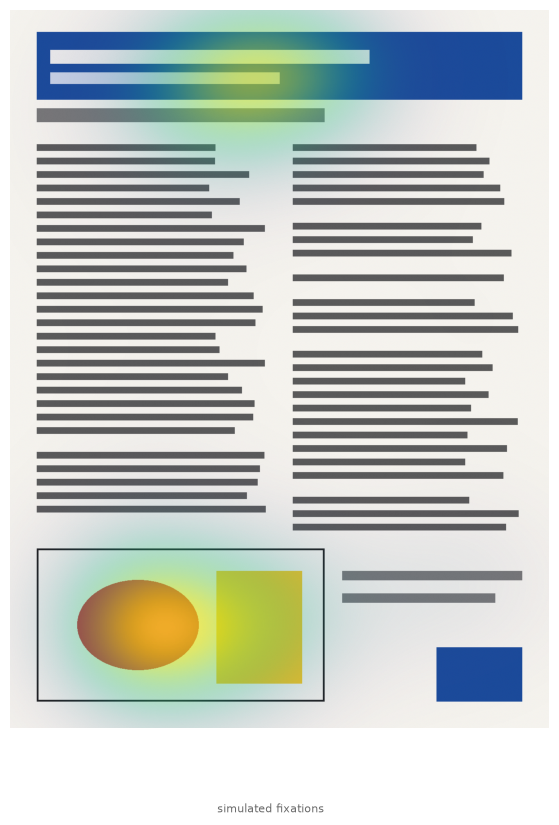

In [11]:
# two more temperaments: the microscope and the weather report
art_2 = attention_map(fix_x, fix_y, poster, bandwidth=25, cmap="magma")
art_3 = attention_map(fix_x, fix_y, poster, bandwidth=160, strength=0.7,
                      cmap="viridis")

**Look and compare.** Three renderings of the identical 200 fixations. The microscope (bandwidth 25) almost shows individual glances: honest about the data, noisy as a picture. The weather report (bandwidth 160) is seductively smooth and claims far more than 200 points can support: the whole poster seems measured. Which of the three would survive review in a scientific paper, and which would sell a redesign to a client? Why are those answers different?

In [12]:
# optional sliders -- everything they do, a direct call does too
def kde_explorer(bandwidth=60, strength=0.85):
    attention_map(fix_x, fix_y, poster, bandwidth=bandwidth, strength=strength,
                  grid_step=6, figsize=5.5)

try:
    from ipywidgets import interact
    interact(kde_explorer, bandwidth=(15, 200, 5), strength=(0.2, 1.0, 0.05))
except ImportError:
    print("ipywidgets is not installed -- call kde_explorer(60, 0.85) directly")

interactive(children=(IntSlider(value=60, description='bandwidth', max=200, min=15, step=5), FloatSlider(value…

## Export your artwork

Design your own audience: edit the `regions` table (a distracted crowd? one that only reads captions?), or follow the Photoshop aside and click fixations onto an image of your own. Pick a bandwidth and colormap that say what you mean, replace `yourname`, and run; the print-quality PNG lands in `assets/outputs/`.

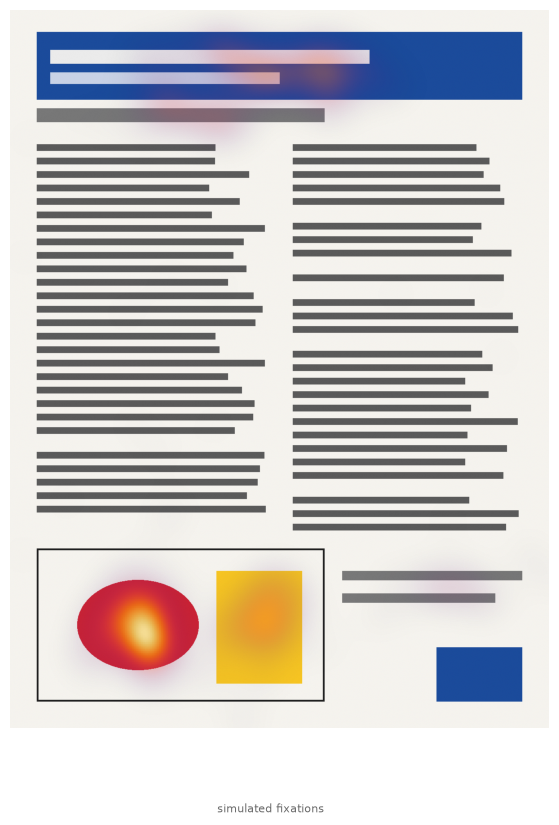

saved: assets/outputs/ch11_yourname.png


In [13]:
# save YOUR artwork: adjust regions, bandwidth, colormap, replace 'yourname'
my_artwork = attention_map(fix_x, fix_y, poster, bandwidth=45, cmap="inferno")
saved_path = save_artwork(my_artwork, "yourname", chapter=11)

## Exercises

**(a) Parameter exploration: where vs that.** Sweep the bandwidth from 15 to 300 in a few steps. Somewhere along the way the map stops showing *where* people looked and starts merely showing *that* they looked. Find the bandwidth where the title cluster and the author cluster first fuse into one blob, and the one where the figure's two sub-clusters (red shape, yellow panel) do. If you had to defend a single "correct" bandwidth for this data, what would your argument even appeal to?

**(b) Code modification: your own image, your own audience.** Load any image (the course paintings in `assets/images/` work; chapter 5 shows the loading pattern), invent three or four fixation regions for it, and render an `attention_map` overlay. Keep it plausible: where would a first-time viewer's gaze pool?

<details><summary>Solution</summary>

```python
wave = np.asarray(Image.open("../assets/images/hokusai_wave.jpg")) / 255
wave_h, wave_w = wave.shape[:2]

rng = np.random.default_rng(7)
wave_regions = [
    (620, 360, 160, 90, 70),     # the claw of the great wave
    (1160, 840, 60, 40, 35),     # Mount Fuji, small but magnetic
    (980, 810, 150, 45, 30),     # the nearer boat and its crew
    (1500, 700, 130, 50, 20),    # the swell on the right
]
wave_x, wave_y = [], []
for center_x, center_y, spread_x, spread_y, count in wave_regions:
    wave_x.extend(rng.normal(center_x, spread_x, count))
    wave_y.extend(rng.normal(center_y, spread_y, count))
wave_x.extend(rng.uniform(0, wave_w, 15))
wave_y.extend(rng.uniform(0, wave_h, 15))

art = attention_map(np.array(wave_x), np.array(wave_y), wave,
                    bandwidth=70, cmap="magma", grid_step=8)
```

Notice what the density does to Fuji: thirty-five fixations on a tiny mountain out-glow seventy spread across the whole wave. KDE rewards concentration, not quantity, which is exactly why small salient details win heatmaps.
</details>

**(c) Creative challenge: the scanpath.** Heatmaps throw away *time*. The scientific alternative is the scanpath rendering: draw each fixation as a circle (area proportional to how long it lasted, if you invent durations), number them in order, and connect consecutive fixations with straight lines (the jumps between fixations are called saccades). Build a `scanpath(xs, ys, image)` function and compare its story to the heatmap's on the same data: one shows a route, the other a climate. Yarbus's famous plates are scanpaths, not heatmaps; look at them again and consider what the heatmap version would have hidden.

## Further reading

- Alfred Yarbus, *Eye Movements and Vision* (Plenum Press, 1967): the original plates are still astonishing; the Repin figures are in chapter 7.
- Robert Solso, *Cognition and the Visual Arts* (MIT Press, 1994): a classic bridge between vision science and art, eye movements included.
- David Borland and Russell Taylor, "Rainbow Color Map (Still) Considered Harmful", *IEEE Computer Graphics and Applications* 27.2 (2007): the case against `jet`, made politely and with pictures.
- The [matplotlib colormap guide](https://matplotlib.org/stable/users/explain/colors/colormaps.html): every built-in map plotted with its lightness profile, so you can see honesty directly.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: the full simulated-attention overlay on a fine grid. It takes a few seconds and runs automatically with *Restart & Run All*.

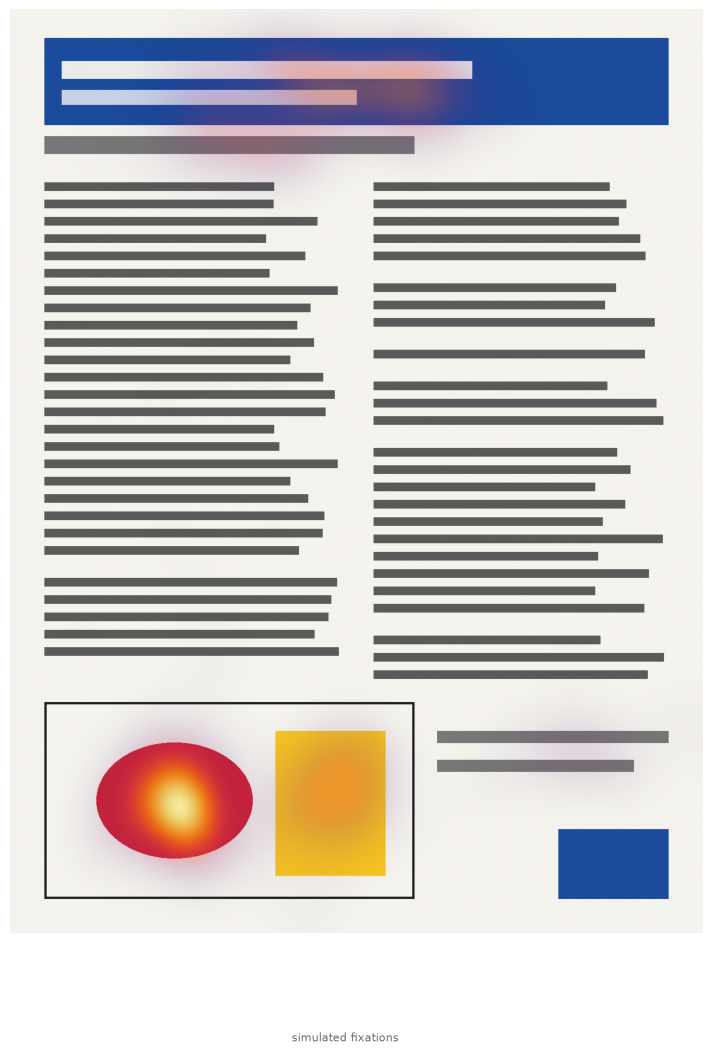

saved: assets/outputs/ch11_showpiece.png


In [14]:
# regenerate this chapter's showpiece: the poster and its simulated audience
showpiece = attention_map(fix_x, fix_y, poster, bandwidth=55, strength=0.9,
                          cmap="inferno", grid_step=2, figsize=9)
saved_path = save_artwork(showpiece, "showpiece", chapter=11)